In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import minimize

In [2]:
# Read Data
data_path = "./data/bird_count.csv"
df = pd.read_csv(data_path)
df = df.sort_values(by="yr")

In [3]:
# Extract Data
years = df["yr"].to_numpy(dtype=int)
years_centered = years - np.min(years)
counts = df["count"].to_numpy(dtype=int)
print(f"years={years}")
print(f"counts={counts}")

years=[1999 2000 2001 2002 2004 2005 2006 2007 2008 2009 2010 2011 2012]
counts=[10  5  9 12 14  8 12  9  5  5  5  2 12]


In [4]:
# Model: Poisson GLM
def poisson_glm(x, y):
    def log_likelihood(coef):
        beta0, beta1 = coef
        eta = beta0 + beta1 * x
        return -np.sum(-np.exp(eta) + y * eta)
    result = minimize(log_likelihood, x0=[0, 0])
    print(result)
    return result.x

In [5]:
# Calculate Coefficients
beta0, beta1 = poisson_glm(x=years_centered, y=counts)
print(f"beta0={beta0}, beta1={beta1}")

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -121.62602224466156
        x: [ 2.325e+00 -3.244e-02]
      nit: 9
      jac: [ 9.537e-07  9.537e-07]
 hess_inv: [[ 2.988e-02 -3.350e-03]
            [-3.350e-03  5.447e-04]]
     nfev: 42
     njev: 14
beta0=2.325331991511667, beta1=-0.032443185304373116


In [ ]:
# Simulation and Write Data
lambdas = np.exp(beta0 + beta1 * years_centered)
rng = np.random.default_rng()

samples = []
for i in range(1, 4):
    counts_sim = rng.poisson(lam=lambdas)
    sample = pd.DataFrame({
        "year": years,
        "counts": counts_sim,
        "simulation": i
    })
    samples.append(sample)

df = pd.concat(samples)
print(df)
df.to_csv("./data/bird_samples.csv")

    year  counts  simulation
0   1999      11           1
1   2000      11           1
2   2001      12           1
3   2002       4           1
4   2004       8           1
5   2005       7           1
6   2006      10           1
7   2007       5           1
8   2008      11           1
9   2009      10           1
10  2010       7           1
11  2011       7           1
12  2012       9           1
0   1999      11           2
1   2000      11           2
2   2001       9           2
3   2002       8           2
4   2004      10           2
5   2005       7           2
6   2006      14           2
7   2007       4           2
8   2008      14           2
9   2009       6           2
10  2010       5           2
11  2011       7           2
12  2012       7           2
0   1999       9           3
1   2000       8           3
2   2001       8           3
3   2002       8           3
4   2004       7           3
5   2005       6           3
6   2006      11           3
7   2007      

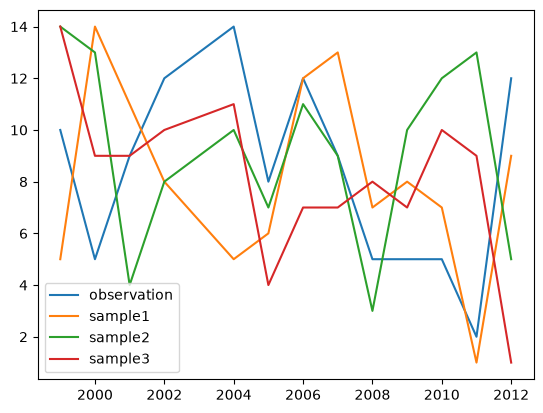

In [8]:
# Plot
fig, ax = plt.subplots()
ax.plot(years, counts)
for sample in samples:
    counts_sim = sample["counts"].to_numpy(dtype=int)
    ax.plot(years, counts_sim)
ax.legend(["observation", "sample1", "sample2", "sample3"])
plt.show()